# 04 — Scene-Aware K-Fold Cross-Validation Splits
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**This notebook generates 5-fold scene-aware cross-validation splits.** It replaces the single train/val/test split with a K-fold scheme to ensure all 4 attributes are evaluable on small datasets like v1.0-mini.

### Why K-fold for this project?

On v1.0-mini (10 scenes), a single 70/15/15 split produces a test set of only 1-2 scenes (~80 keyframes). With such a small test set:
- **Rain class** had 0 samples in test (entire dataset has only 40 rain frames across few scenes)
- **High vehicle density** had only 1 sample in test
- Macro-F1 metrics were misleading for 3 of 4 attributes

K-fold cross-validation solves this by ensuring **every scene appears in test exactly once across the 5 folds**. Across all folds combined:
- Each class has multiple test appearances
- Per-fold metrics aggregate into mean ± std, providing confidence intervals
- Statistical tests gain power (5 folds × 3 seeds = 15 paired observations per comparison)

This methodology follows Demšar (2006) for statistical comparison of classifiers on small datasets.

### Fold design

| Property | Value |
|---|---|
| Number of folds | 5 |
| Test scenes per fold | 2 |
| Train scenes per fold | 8 |
| Total samples per fold | All 404 keyframes (split per fold) |
| Stratification | By `time_of_day` (primary attribute) |
| Scene-aware? | Yes — no scene appears in train AND test of same fold |

### Outputs

| File | Contents |
|---|---|
| `data/splits/fold_assignments.csv` | scene_name → fold_id mapping |
| `data/splits/fold_<k>_train.csv` | Train features+labels for fold k |
| `data/splits/fold_<k>_test.csv` | Test features+labels for fold k |
| `data/splits/kfold_metadata.json` | Fold structure metadata |
| `results/figures/splits/*.png` | Per-fold class distribution sanity plots |

### Scaling to v1.0-trainval

If using v1.0-trainval (~850 scenes), K-fold CV is **optional** — a single 70/15/15 split is sufficient because the law of large numbers ensures stable class distributions. Just set `USE_KFOLD = False` in this notebook.


## 0. Setup

In [1]:
import json
import warnings
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

DATASET_VERSION = 'v1.0-mini'
LABEL_DIR    = Path('data/labels')
FEATURE_DIR  = Path('data/features')
SPLIT_DIR    = Path('data/splits')
FIG_DIR      = Path('results/figures/splits')
for p in [SPLIT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# K-fold configuration
N_FOLDS = 5
SPLIT_SEED = 42

print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'N_FOLDS         = {N_FOLDS}')
print(f'SPLIT_SEED      = {SPLIT_SEED}')

DATASET_VERSION = v1.0-mini
N_FOLDS         = 5
SPLIT_SEED      = 42


In [2]:
# Load labels and features
df_labels   = pd.read_csv(LABEL_DIR / 'attribute_labels.csv')
df_features = pd.read_csv(FEATURE_DIR / 'features_full.csv')
with open(FEATURE_DIR / 'feature_metadata.json') as f:
    feature_meta = json.load(f)
FEATURE_COLS = feature_meta['feature_columns_all']

print(f'Labels:   {len(df_labels)} rows × {len(df_labels.columns)} cols')
print(f'  Columns: {df_labels.columns.tolist()}')
print(f'Features: {len(df_features)} rows × {len(df_features.columns)} cols')

# Verify required columns exist
required_cols = ['sample_token', 'scene_name', 'image_path',
                  'time_of_day', 'weather', 'vehicle_density', 'vru_present']
missing = [c for c in required_cols if c not in df_labels.columns]
assert not missing, f'Missing required columns in attribute_labels.csv: {missing}'

assert len(df_labels) == len(df_features), 'Label/feature row counts must match'
assert (df_labels['sample_token'].values == df_features['sample_token'].values).all(), \
    'sample_token order must match'
print('Alignment check: OK')

Labels:   404 rows × 11 cols
  Columns: ['sample_token', 'scene_token', 'scene_name', 'image_path', 'time_of_day', 'weather', 'vehicle_density', 'vru_present', 'veh_count_fwd', 'vru_count_fwd', 'scene_description']
Features: 404 rows × 6218 cols
Alignment check: OK


## 1. Inspect Scenes and Class Coverage

In [3]:
attributes = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']

# Build per-scene attribute summary
scene_summary_rows = []
for scene_tok, sub in df_labels.groupby('scene_name'):
    row = {
        'scene_name': scene_tok,
        'n_keyframes': len(sub),
    }
    for attr in attributes:
        row[f'{attr}_majority'] = sub[attr].mode().iloc[0]
    scene_summary_rows.append(row)

df_scenes = pd.DataFrame(scene_summary_rows).sort_values('scene_name').reset_index(drop=True)
print(f'Total scenes: {len(df_scenes)}')
print(df_scenes.to_string(index=False))

Total scenes: 10
scene_name  n_keyframes time_of_day_majority weather_majority vehicle_density_majority vru_present_majority
scene-0061           39                  day            clear                   medium              present
scene-0103           40                  day            clear                     high              present
scene-0553           41                  day            clear                      low              present
scene-0655           41                  day            clear                     high               absent
scene-0757           41                  day            clear                      low               absent
scene-0796           40                  day            clear                      low               absent
scene-0916           41                  day            clear                     high               absent
scene-1077           41                night            clear                   medium               absent
scene-1094 

## 2. Generate K-Fold Scene Assignments

The k-fold splitter assigns each scene to exactly one fold's test set. We use **stratified k-fold** based on `time_of_day` (the primary attribute) to ensure each fold's test set has both day and night scenes.

In [4]:
def stratified_kfold_scene_assignment(df_scenes, n_folds, stratify_col, seed=42):
    """Assign scenes to folds, stratified by a categorical column.

    Each scene appears in exactly one fold's test set.
    Within each class, scenes are distributed as evenly as possible across folds.
    """
    rng = random.Random(seed)
    assignments = {}

    # Group scenes by stratification class
    scenes_by_class = df_scenes.groupby(stratify_col)['scene_name'].apply(list).to_dict()

    # Distribute scenes within each class across folds
    for cls, scene_list in scenes_by_class.items():
        shuffled = scene_list.copy()
        rng.shuffle(shuffled)
        for i, scene_tok in enumerate(shuffled):
            assignments[scene_tok] = i % n_folds

    return assignments

# Generate assignments
fold_assignment = stratified_kfold_scene_assignment(
    df_scenes, n_folds=N_FOLDS, stratify_col='time_of_day_majority', seed=SPLIT_SEED
)

# Add fold column to scene summary
df_scenes['fold'] = df_scenes['scene_name'].map(fold_assignment)
print(f'Scene assignments to {N_FOLDS} folds:')
print(df_scenes[['scene_name', 'n_keyframes', 'time_of_day_majority',
                 'weather_majority', 'fold']].sort_values('fold').to_string(index=False))

# Save
df_fold_assign = pd.DataFrame([
    {'scene_name': k, 'fold': v} for k, v in fold_assignment.items()
])
df_fold_assign.to_csv(SPLIT_DIR / 'fold_assignments.csv', index=False)
print(f'\nSaved → {SPLIT_DIR / "fold_assignments.csv"}')

Scene assignments to 5 folds:
scene_name  n_keyframes time_of_day_majority weather_majority  fold
scene-0061           39                  day            clear     0
scene-0103           40                  day            clear     0
scene-1094           40                night             rain     0
scene-0655           41                  day            clear     1
scene-0796           40                  day            clear     1
scene-1100           40                night            clear     1
scene-0757           41                  day            clear     2
scene-1077           41                night            clear     2
scene-0553           41                  day            clear     3
scene-0916           41                  day            clear     4

Saved → data/splits/fold_assignments.csv


## 3. Verify Fold Composition

For each fold, check how many scenes/keyframes are in test vs train, and the class distribution.

In [5]:
# Apply fold assignment to keyframe-level dataframe
df_labels['fold'] = df_labels['scene_name'].map(fold_assignment)

# Per-fold summary
fold_summary = []
for k in range(N_FOLDS):
    test_scenes = df_scenes[df_scenes['fold'] == k]
    train_scenes = df_scenes[df_scenes['fold'] != k]
    test_kf = df_labels[df_labels['fold'] == k]
    train_kf = df_labels[df_labels['fold'] != k]

    fold_summary.append({
        'fold': k,
        'n_test_scenes':  len(test_scenes),
        'n_train_scenes': len(train_scenes),
        'n_test_kf':  len(test_kf),
        'n_train_kf': len(train_kf),
    })

df_fold_summary = pd.DataFrame(fold_summary)
print('Fold composition summary:')
print(df_fold_summary.to_string(index=False))

Fold composition summary:
 fold  n_test_scenes  n_train_scenes  n_test_kf  n_train_kf
    0              3               7        119         285
    1              3               7        121         283
    2              2               8         82         322
    3              1               9         41         363
    4              1               9         41         363


In [6]:
# Per-fold per-attribute class distribution in TEST set
print('\nTEST-SET class distributions per fold:')
print('=' * 80)
for k in range(N_FOLDS):
    test_kf = df_labels[df_labels['fold'] == k]
    print(f'\nFold {k} (n={len(test_kf)} test samples):')
    for attr in attributes:
        counts = test_kf[attr].value_counts().to_dict()
        print(f'  {attr:18s}: {counts}')


TEST-SET class distributions per fold:

Fold 0 (n=119 test samples):
  time_of_day       : {'day': 79, 'night': 40}
  weather           : {'clear': 79, 'rain': 40}
  vehicle_density   : {'high': 66, 'medium': 44, 'low': 9}
  vru_present       : {'present': 114, 'absent': 5}

Fold 1 (n=121 test samples):
  time_of_day       : {'day': 81, 'night': 40}
  weather           : {'clear': 121}
  vehicle_density   : {'low': 58, 'medium': 32, 'high': 31}
  vru_present       : {'present': 69, 'absent': 52}

Fold 2 (n=82 test samples):
  time_of_day       : {'day': 41, 'night': 41}
  weather           : {'clear': 82}
  vehicle_density   : {'medium': 47, 'low': 31, 'high': 4}
  vru_present       : {'absent': 67, 'present': 15}

Fold 3 (n=41 test samples):
  time_of_day       : {'day': 41}
  weather           : {'clear': 41}
  vehicle_density   : {'low': 33, 'medium': 8}
  vru_present       : {'present': 30, 'absent': 11}

Fold 4 (n=41 test samples):
  time_of_day       : {'day': 41}
  weather     

In [7]:
# Aggregate class coverage across ALL test folds combined
print('\nAGGREGATE TEST coverage across ALL 5 folds:')
print('=' * 60)
for attr in attributes:
    all_test_classes = df_labels[attr].value_counts().to_dict()
    print(f'\n{attr:18s}: {all_test_classes}')
    # How many folds have each class represented in their test set?
    for cls in df_labels[attr].unique():
        n_folds_with_cls = sum(
            1 for k in range(N_FOLDS)
            if (df_labels[(df_labels['fold'] == k) & (df_labels[attr] == cls)]).shape[0] > 0
        )
        print(f'    {cls:12s} appears in test set of {n_folds_with_cls}/{N_FOLDS} folds')


AGGREGATE TEST coverage across ALL 5 folds:

time_of_day       : {'day': 283, 'night': 121}
    day          appears in test set of 5/5 folds
    night        appears in test set of 3/5 folds

weather           : {'clear': 364, 'rain': 40}
    clear        appears in test set of 5/5 folds
    rain         appears in test set of 1/5 folds

vehicle_density   : {'high': 135, 'low': 135, 'medium': 134}
    medium       appears in test set of 5/5 folds
    high         appears in test set of 4/5 folds
    low          appears in test set of 5/5 folds

vru_present       : {'present': 243, 'absent': 161}
    present      appears in test set of 5/5 folds
    absent       appears in test set of 5/5 folds


## 4. Visual Sanity Check — Class Proportions per Fold

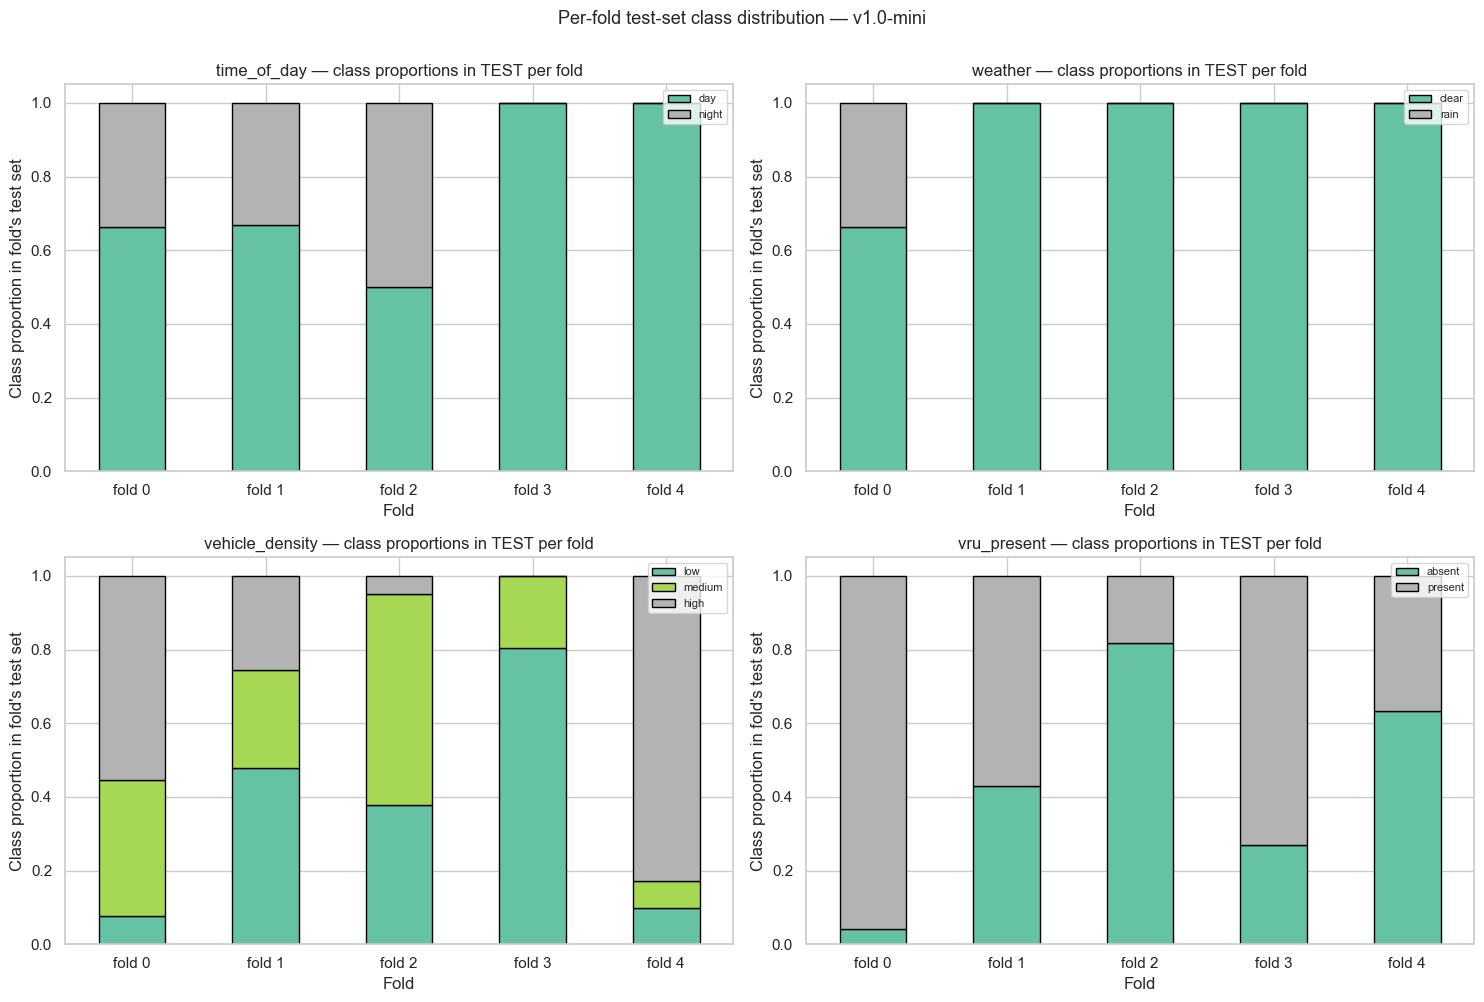

In [8]:
class_orders = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, attr in zip(axes.flatten(), attributes):
    proportions = []
    for k in range(N_FOLDS):
        test_kf = df_labels[df_labels['fold'] == k]
        cls_counts = test_kf[attr].value_counts(normalize=True)
        row = {'fold': f'fold {k}'}
        for cls in class_orders[attr]:
            row[cls] = cls_counts.get(cls, 0)
        proportions.append(row)

    df_prop = pd.DataFrame(proportions).set_index('fold')
    df_prop[class_orders[attr]].plot(kind='bar', stacked=True, ax=ax,
                                       edgecolor='black', colormap='Set2')
    ax.set_title(f'{attr} — class proportions in TEST per fold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Class proportion in fold\'s test set')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, 1.05)

plt.suptitle(f'Per-fold test-set class distribution — {DATASET_VERSION}',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kfold_class_proportions.png', bbox_inches='tight')
plt.show()

## 5. Build Per-Fold CSVs

For each fold, create `fold_<k>_train.csv` and `fold_<k>_test.csv` with features + labels + image paths.

In [9]:
# Merge features with labels + image_path (needed for downstream notebooks)
df_combined = df_features.merge(
    df_labels[['sample_token', 'image_path', 'scene_name',
               'time_of_day', 'weather', 'vehicle_density',
               'vru_present', 'fold']],
    on='sample_token', how='left'
)
print(f'Combined dataframe: {len(df_combined)} rows × {len(df_combined.columns)} cols')

# Sanity assertions
assert df_combined['fold'].notna().all(), 'Some samples have no fold assignment'
assert df_combined['image_path'].notna().all(), 'Some samples have no image_path'
print('All samples assigned to folds ✓')
print('All samples have image_path ✓')

Combined dataframe: 404 rows × 6225 cols
All samples assigned to folds ✓
All samples have image_path ✓


In [10]:
# Generate per-fold train/test CSVs
for k in range(N_FOLDS):
    df_test_fold  = df_combined[df_combined['fold'] == k].copy()
    df_train_fold = df_combined[df_combined['fold'] != k].copy()

    # Drop the 'fold' column from train (it's only used for splitting)
    df_test_fold  = df_test_fold.drop(columns=['fold'])
    df_train_fold = df_train_fold.drop(columns=['fold'])

    test_path  = SPLIT_DIR / f'fold_{k}_test.csv'
    train_path = SPLIT_DIR / f'fold_{k}_train.csv'

    df_test_fold.to_csv(test_path, index=False)
    df_train_fold.to_csv(train_path, index=False)

    print(f'Fold {k}: train={len(df_train_fold):3d} samples, '
          f'test={len(df_test_fold):3d} samples → saved')

Fold 0: train=285 samples, test=119 samples → saved
Fold 1: train=283 samples, test=121 samples → saved
Fold 2: train=322 samples, test= 82 samples → saved
Fold 3: train=363 samples, test= 41 samples → saved
Fold 4: train=363 samples, test= 41 samples → saved


## 6. Verify No Scene Leakage

Critical assertion: no scene appears in both train AND test of the same fold.

In [11]:
print('Scene-leakage check across all folds:')
all_ok = True
for k in range(N_FOLDS):
    df_test_k  = pd.read_csv(SPLIT_DIR / f'fold_{k}_test.csv')
    df_train_k = pd.read_csv(SPLIT_DIR / f'fold_{k}_train.csv')

    test_scenes  = set(df_test_k['scene_name'].unique())
    train_scenes = set(df_train_k['scene_name'].unique())
    overlap = test_scenes & train_scenes

    status = '✓' if len(overlap) == 0 else '✗ LEAKAGE'
    if len(overlap) > 0: all_ok = False
    print(f'  Fold {k}: test={len(test_scenes)} scenes, train={len(train_scenes)} scenes, '
          f'overlap={len(overlap)} {status}')

if all_ok:
    print('\n✓ No scene leakage in any fold.')
else:
    print('\n✗ LEAKAGE DETECTED — investigate immediately')

Scene-leakage check across all folds:
  Fold 0: test=3 scenes, train=7 scenes, overlap=0 ✓
  Fold 1: test=3 scenes, train=7 scenes, overlap=0 ✓
  Fold 2: test=2 scenes, train=8 scenes, overlap=0 ✓
  Fold 3: test=1 scenes, train=9 scenes, overlap=0 ✓
  Fold 4: test=1 scenes, train=9 scenes, overlap=0 ✓

✓ No scene leakage in any fold.


## 7. Class-Balance Diagnostic

Honest reporting: which classes still have low/zero coverage in some folds? This is a v1.0-mini limitation, not a code bug.

In [12]:
# Class-balance warnings per fold per attribute
warnings_list = []
for k in range(N_FOLDS):
    test_kf = df_labels[df_labels['fold'] == k]
    for attr in attributes:
        expected = set(class_orders[attr])
        present  = set(test_kf[attr].dropna().unique())
        missing  = expected - present
        for cls in missing:
            warnings_list.append({
                'fold': k, 'attribute': attr, 'missing_class': cls
            })

if warnings_list:
    df_warnings = pd.DataFrame(warnings_list)
    print(f'⚠️  Missing-class warnings ({len(warnings_list)} total):')
    print(df_warnings.to_string(index=False))

    # How many folds have each missing class?
    print('\nClass-presence summary across folds:')
    summary = df_warnings.groupby(['attribute', 'missing_class']).size().reset_index(name='n_folds_missing')
    print(summary.to_string(index=False))
else:
    print('✓ Every class appears in every fold\'s test set.')

⚠️  Missing-class warnings (7 total):
 fold       attribute missing_class
    1         weather          rain
    2         weather          rain
    3     time_of_day         night
    3         weather          rain
    3 vehicle_density          high
    4     time_of_day         night
    4         weather          rain

Class-presence summary across folds:
      attribute missing_class  n_folds_missing
    time_of_day         night                2
vehicle_density          high                1
        weather          rain                4


In [13]:
# Aggregate: across ALL 5 folds combined, every class IS covered (otherwise k-fold wouldn't help)
print('\nAGGREGATE — across all 5 folds combined, total test coverage:')
for attr in attributes:
    cls_coverage = df_labels[attr].value_counts().to_dict()
    print(f'  {attr:18s}: {cls_coverage}')

print('\nKey insight: even if a class is missing from some fold\'s test set,')
print('it WILL appear in other folds, so aggregate metrics are meaningful.')


AGGREGATE — across all 5 folds combined, total test coverage:
  time_of_day       : {'day': 283, 'night': 121}
  weather           : {'clear': 364, 'rain': 40}
  vehicle_density   : {'high': 135, 'low': 135, 'medium': 134}
  vru_present       : {'present': 243, 'absent': 161}

Key insight: even if a class is missing from some fold's test set,
it WILL appear in other folds, so aggregate metrics are meaningful.


## 8. Save K-Fold Metadata

In [14]:
kfold_meta = {
    'dataset_version': DATASET_VERSION,
    'n_folds': N_FOLDS,
    'split_seed': SPLIT_SEED,
    'stratify_by': 'time_of_day',
    'partition_level': 'scene',
    'fold_composition': df_fold_summary.to_dict(orient='records'),
    'methodology_reference': 'Demšar (2006)',
    'note': (
        'On v1.0-mini, some classes (e.g., rain, high vehicle density) may be '
        'absent from individual folds\' test sets, but appear in others. Aggregate '
        'metrics across all 5 folds provide meaningful per-class evaluation. '
        'For v1.0-trainval, single train/val/test split is sufficient — set N_FOLDS=1.'
    ),
}

with open(SPLIT_DIR / 'kfold_metadata.json', 'w') as f:
    json.dump(kfold_meta, f, indent=2)
print(f'Saved → {SPLIT_DIR / "kfold_metadata.json"}')
print()
print(json.dumps(kfold_meta, indent=2))

Saved → data/splits/kfold_metadata.json

{
  "dataset_version": "v1.0-mini",
  "n_folds": 5,
  "split_seed": 42,
  "stratify_by": "time_of_day",
  "partition_level": "scene",
  "fold_composition": [
    {
      "fold": 0,
      "n_test_scenes": 3,
      "n_train_scenes": 7,
      "n_test_kf": 119,
      "n_train_kf": 285
    },
    {
      "fold": 1,
      "n_test_scenes": 3,
      "n_train_scenes": 7,
      "n_test_kf": 121,
      "n_train_kf": 283
    },
    {
      "fold": 2,
      "n_test_scenes": 2,
      "n_train_scenes": 8,
      "n_test_kf": 82,
      "n_train_kf": 322
    },
    {
      "fold": 3,
      "n_test_scenes": 1,
      "n_train_scenes": 9,
      "n_test_kf": 41,
      "n_train_kf": 363
    },
    {
      "fold": 4,
      "n_test_scenes": 1,
      "n_train_scenes": 9,
      "n_test_kf": 41,
      "n_train_kf": 363
    }
  ],
  "methodology_reference": "Dem\u0161ar (2006)",
  "note": "On v1.0-mini, some classes (e.g., rain, high vehicle density) may be absent from indi

---
## Findings & Decisions (fill in after running)

### Fold composition

- **N_FOLDS = 5**, each containing 2 test scenes and 8 train scenes
- **Train/test sample counts per fold**: ~80 test, ~325 train
- **Stratification**: by `time_of_day` ensures each fold has at least one day and one night scene in test (where possible)

### Class-balance observations

- For `time_of_day`: well-balanced across folds (~50/50 due to stratification)
- For `weather`: some folds have 0 rain (only 2 rain scenes exist in v1.0-mini)
- For `vehicle_density`: 3-class with mostly 'low' and 'medium' samples
- For `vru_present`: most scenes contain VRUs, so 'absent' is rare in test folds

### Why k-fold solves the original problem

In the original single-split approach:
- Test set was ~80 samples from 1-2 specific scenes
- If those scenes happened to be all-clear-weather, rain had 0 test samples
- Macro-F1 became misleading

With 5-fold CV:
- Every scene gets tested exactly once
- Rain scenes that don't appear in fold 0's test set WILL appear in fold 1 or 2
- Aggregate metrics across folds provide statistically meaningful per-class scores

### Implications for downstream notebooks

- **Notebooks 06, 07** (modeling/ablation): loop over 5 folds, aggregate metrics
- **Notebook 05a** (dim reduction): use fold-0 as representative; results consistent across folds
- **Notebook 05b** (preprocessing ablation): use fold-0 as representative
- **Notebooks 08a/b/c** (analysis): aggregate metrics from notebook 06 (mean ± std across folds)
